# Workshop on Semantic Similarity

The objective of the workshop is to compare embedding models for information retrieval tasks

Models:
* BERT (MLM) + mean pooling
* all-MiniLM (contrastive, sentence-level, BERT)
* E5 (contrastive retrieval, uses "query:" and "passage:" prefixes)
* Cross-Encoder Reranker (scores query-passage pairs directly)
* BM25 (keyword-based ranking, no embeddings) - not an actual machine learning model


If you're running this in a fresh environment (e.g. Colab), run the next cell once to install the dependencies.

In [ ]:
# Install dependencies (run once per environment; may require restart)
%pip install torch transformers sentence-transformers matplotlib numpy rank-bm25

#### Class to load ML models and encode text to embeddings

In [9]:
import torch
from transformers import AutoTokenizer, AutoModel
from sentence_transformers import SentenceTransformer, CrossEncoder 
from rank_bm25 import BM25Okapi 
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import re
import time

# === CONFIGURATION ===

MODEL_CONFIGS = {
    "BERT": {
        "tokenizer": "bert-base-uncased",
        "model": "bert-base-uncased",
        "type": "transformer"
    },
    "MiniLM-L6": {
        "model": "sentence-transformers/all-MiniLM-L6-v2",
        "type": "sentence_transformer"
    },
    "E5": {
        "tokenizer": "intfloat/e5-small-v2",
        "model": "intfloat/e5-small-v2",
        "type": "e5"
    },
    "Reranker (cross-encoder)": {
        "model": "cross-encoder/ms-marco-MiniLM-L-6-v2",
        "type": "cross_encoder"
    }
}

# === UTILITY FUNCTIONS ===

def load_model(model_class, model_name, **kwargs):
    """Try to load model from cache first, download if not available."""
    try:
        # SentenceTransformer uses __init__ not from_pretrained
        if model_class == SentenceTransformer or model_class == CrossEncoder:
            return model_class(model_name, local_files_only=True, **kwargs)
        else:
            return model_class.from_pretrained(model_name, local_files_only=True, **kwargs)
    except Exception:
        print(f"Model {model_name} not cached, downloading...")
        if model_class == SentenceTransformer or model_class == CrossEncoder:
            return model_class(model_name, **kwargs)
        else:
            return model_class.from_pretrained(model_name, **kwargs)

def mean_pool(last_hidden_state, attention_mask):
    """Mean pooling that excludes padding tokens using attention_mask."""
    masked = last_hidden_state * attention_mask.unsqueeze(-1)
    return masked.sum(dim=1) / attention_mask.sum(dim=1, keepdim=True)

def tokenize(text):
    """Simple tokenization for BM25"""
    text = text.lower()
    text = re.sub(r'[^\w\s]', ' ', text)
    return text.split()

# === MODEL MANAGER ===

class ModelManager:
    """Manages loading and encoding for all embedding models"""

    def __init__(self, device="cpu"):
        self.device = device
        self.models = {}
        self.tokenizers = {}
        self.encoding_times = {}

    def load_all_models(self):
        """Load all models defined in MODEL_CONFIGS"""
        print("Loading models...")

        for model_name, config in MODEL_CONFIGS.items():
            if config["type"] == "transformer":
                self.tokenizers[model_name] = load_model(AutoTokenizer, config["tokenizer"])
                self.models[model_name] = load_model(AutoModel, config["model"]).to(self.device).eval()
            elif config["type"] == "sentence_transformer":
                self.models[model_name] = load_model(SentenceTransformer, config["model"], device=self.device)
            elif config["type"] == "e5":
                self.tokenizers[model_name] = load_model(AutoTokenizer, config["tokenizer"])
                self.models[model_name] = load_model(AutoModel, config["model"]).to(self.device).eval()
            elif config["type"] == "cross_encoder":
                self.models[model_name] = load_model(CrossEncoder, config["model"])

        print("Models loaded.\n")

    def encode_bert(self, texts, model_name="BERT"):
        """Encode texts using BERT with mean pooling"""
        tokenizer = self.tokenizers[model_name]
        model = self.models[model_name]

        with torch.no_grad():
            inputs = tokenizer(texts, padding=True, truncation=True, return_tensors="pt").to(self.device)
            outputs = model(**inputs)
            embeddings = mean_pool(outputs.last_hidden_state, inputs["attention_mask"])
            embeddings = torch.nn.functional.normalize(embeddings, p=2, dim=1).cpu().numpy()
        return embeddings

    def encode_sbert(self, texts, model_name="MiniLM-L6"):
        """Encode texts using Sentence-BERT"""
        model = self.models[model_name]
        return model.encode(texts, normalize_embeddings=True, convert_to_numpy=True)

    def encode_e5(self, texts, prefix_type, model_name="E5"):
        """Encode texts with E5 using specified prefix"""
        tokenizer = self.tokenizers[model_name]
        model = self.models[model_name]

        with torch.no_grad():
            prefixed_texts = [f"{prefix_type}: {text}" for text in texts]
            inputs = tokenizer(prefixed_texts, padding=True, truncation=True, return_tensors="pt").to(self.device)
            outputs = model(**inputs)
            embeddings = mean_pool(outputs.last_hidden_state, inputs["attention_mask"])
            embeddings = torch.nn.functional.normalize(embeddings, p=2, dim=1).cpu().numpy()
        return embeddings

    def encode_all(self, queries, passages):
        """Encode queries and passages with all models"""
        model_embeddings = {}

        # BERT
        print("Encoding with BERT...")
        start_time = time.time()
        bert_query_emb = self.encode_bert(queries)
        bert_passage_emb = self.encode_bert(passages)
        model_embeddings["BERT"] = (bert_query_emb, bert_passage_emb)
        self.encoding_times["BERT"] = time.time() - start_time

        # SBERT
        print("Encoding with SBERT...")
        start_time = time.time()
        sbert_query_emb = self.encode_sbert(queries)
        sbert_passage_emb = self.encode_sbert(passages)
        model_embeddings["MiniLM-L6"] = (sbert_query_emb, sbert_passage_emb)
        self.encoding_times["MiniLM-L6"] = time.time() - start_time

        # E5
        print("Encoding with E5 (using 'query:' and 'passage:' prefixes)...")
        start_time = time.time()
        e5_query_emb = self.encode_e5(queries, "query")
        e5_passage_emb = self.encode_e5(passages, "passage")
        model_embeddings["E5"] = (e5_query_emb, e5_passage_emb)
        self.encoding_times["E5"] = time.time() - start_time

        # Reranker timing tracked during similarity computation
        self.encoding_times["Reranker (cross-encoder)"] = 0.0

        return model_embeddings

def build_bm25_index(passages):
    """Build BM25 index for keyword-based retrieval"""
    print("Building BM25 index...")
    start_time = time.time()
    tokenized_passages = [tokenize(passage) for passage in passages]
    bm25_index = BM25Okapi(tokenized_passages)
    return bm25_index, time.time() - start_time

#### Query-passage data

In [10]:
query_data = [
    {
        "query": "Explain Python list comprehensions",
        "relevant": "in Python, list comprehensions create lists from iterables using a single concise expression: [f(x) for x in xs if cond(x)]",
        "distractors": [
            "Python list comprehensions are generally faster than equivalent for loops due to optimized C-level iteration",
            "Comprehensions are constructs that allow sequences to be built from other sequences",
            "List comprehensions in Python have similar syntax to set comprehensions and dict comprehensions"
        ]
    },
    {
        "query": "What is the capital of France?",
        "relevant": "Paris is the capital and most populous city of France, serving as the country's political, economic, and cultural center",
        "distractors": [
            "Paris is the city of romance par excellence, the fashion capital and the best example of French art de vivre",
            "Discover the official Paris city pass that lets you put together your own programme of Parisian activities",
            "The French government operates through a semi-presidential system with the president residing at the Élysée Palace"
        ]
    },
    {
        "query": "Nearest star to Earth after the Sun?",
        "relevant": "Proxima Centauri is the closest known star to Earth after the Sun",
        "distractors": [
            "The nearest stars to Earth after the Sun are within a few light-years in our local stellar neighborhood",
            "Barnard's Star is one of the nearest stars to Earth and has the largest proper motion of any known star",
            "After the Sun, the next nearest bright star visible from Earth is Sirius at 8.6 light-years away"
        ]
    },
    {
        "query": "What is the boiling point of water?",
        "relevant": "At 1 atm, pure water boils at 100 degrees Celsius",
        "distractors": [
            "Water freezes at 0 degrees Celsius and exists as ice below this temperature at standard atmospheric pressure",
            "The density of water reaches its maximum at approximately 4 degrees Celsius, which is why ice floats",
            "At high altitudes like Mount Everest, water boils at around 70 degrees Celsius due to lower atmospheric pressure"
        ]
    },
    {
        "query": "Who wrote Pride and Prejudice?",
        "relevant": "Jane Austen wrote Pride and Prejudice, published in 1813",
        "distractors": [
            "Pride and Prejudice was initially published anonymously in 1813 and explores themes of class and social prejudice",
            "The novel Pride and Prejudice has been adapted numerous times for film, television, and stage productions",
            "Pride and Prejudice is considered one of the greatest novels in English literature, written during the Romantic period"
        ]
    },
    {
        "query": " what do chameleons eat?",
        "relevant": "Chameleons are insectivores. Their diet in the wild consists primarily of a wide variety of insects and other invertebrates. In addition to hunting live prey, some chameleon species are also occasionally observed eating plant vegetation",
        "distractors": [
            "What do I feed my chameleon? How do I feed? What do I feed my chameleon's food? Where do I store the food? Are you asking your self these questions? We will cover all this and more!",
            "There is a bone in the back of their throat that propels the tongue kind of like a bow and arrow. Their aim is very accurate for catching insects.",
            "I keep my chameleon cage stocked with flowering plants (mainly orchids) and they sometimes eat the flowers"
        ]
    },
    {
        "query": "Who is zohran mamdani?",
        "relevant": "Zohran Kwame Mamdani[c] (born October 18, 1991) is an American politician who has served since 2026 as the 112th mayor of New York City",
        "distractors": [
            "Charismatic and relatable, the 34-year old energized voters and provided a blueprint for other progressives to follow",
            "Zohran Kwame Mamdani was born and raised in Kampala, Uganda, moving to New York City with his family at the age of 7",
            "Zohran Mamdani, né le 18 octobre 1991 à Kampala (Ouganda), est un homme politique américain. Membre du Parti démocrate et affilié aux Socialistes démocrates"
        ]
    },
    {
        "query": "Git command to clone a repository?",
        "relevant": "Use: git clone <repository_url>",
        "distractors": [
            "The Git command 'git pull' updates a local repository by fetching and merging changes from a remote",
            "To clone a Git repository, you first need the repository URL from platforms like GitHub or GitLab",
            "Git repository commands include clone, push, pull, fetch, and commit for version control operations"
        ]
    },
    {
        "query": "How to fix TypeError: 'int' object is not iterable in Python",
        "relevant": "TypeError: 'int' object is not iterable occurs when trying to iterate over an integer instead of a sequence",
        "distractors": [
            "Python TypeError exceptions are raised when an operation is applied to an object of inappropriate type",
            "The 'int' object in Python has methods like bit_length(), to_bytes(), and from_bytes() for integer operations",
            "'int' object is not iterable is one of many common Python errors along with IndexError and KeyError"
        ]
    },
    {
        "query": "what is hexadecimal",
        "relevant": "Hexadecimal (hex for short) is a positional numeral system for representing a numeric value as base 16",
        "distractors": [
            "Hexadecimal is like any other number or counting system. The systems differ mathematically regarding their base",
            "In Computer Science hexadecimal is often preferred when working with large values",
            "The table below shows how the hexadecimal system works and its equivalent decimal number"
        ]
    }
]

queries = [item["query"] for item in query_data]
all_passages = []
for item in query_data:
    all_passages.append(item["relevant"])
    all_passages.extend(item["distractors"])

print(f"Loaded {len(query_data)} query sets")

Loaded 10 query sets


#### Load models, encode embeddings

In [11]:
import os
os.environ["TOKENIZERS_PARALLELISM"] = "false"

# Set device
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}\n")

# Initialize model manager and load all models
model_manager = ModelManager(device=device)
model_manager.load_all_models()

# Encode all texts with all models, except BM25 (not a ML model) and reranker (no embeddings)
model_embeddings = model_manager.encode_all(queries, all_passages)

# Build BM25 index
bm25_index, bm25_time = build_bm25_index(all_passages)
model_manager.encoding_times["BM25 (keyword-based)"] = bm25_time

# Get reranker
reranker = model_manager.models["Reranker (cross-encoder)"]

all_model_names = ["BM25 (keyword-based)"] + list(model_embeddings.keys()) + ["Reranker (cross-encoder)"]

Using device: cpu

Loading models...
Models loaded.

Encoding with BERT...
Encoding with SBERT...
Encoding with E5 (using 'query:' and 'passage:' prefixes)...
Building BM25 index...


#### Compute similarities for all query-passage pairs for all models

In [12]:
# Run evaluation
def compute_all_similarities(queries, all_passages, model_embeddings, bm25_index, reranker, tokenize, encoding_times):
    """Compute similarities for all queries and all models once.
    
    Returns:
        - similarities_tensor: np.array of shape (num_queries, num_models, 4)
    """    
    # Compute similarities for all queries
    all_similarities = []
    for q_idx in range(len(queries)):
        query_similarities = []
        query_text = queries[q_idx]
        start_idx = q_idx * 4
        passage_indices = range(start_idx, start_idx + 4)
        
        # BM25 scores
        all_scores = bm25_index.get_scores(tokenize(query_text))
        bm25_similarities = np.array([all_scores[idx] for idx in passage_indices])
        query_similarities.append(bm25_similarities)
        
        # Embedding-based models (in dict order)
        for model_name, (q_emb, p_emb) in model_embeddings.items():
            query_vec = q_emb[q_idx:q_idx+1]
            candidates = p_emb[start_idx:start_idx+4]
            similarities = np.dot(query_vec, candidates.T)[0]
            query_similarities.append(similarities)
        
        # Reranker scores
        start_time = time.time()
        candidates = [all_passages[idx] for idx in passage_indices]
        pairs = [[query_text, passage] for passage in candidates]
        reranker_scores = reranker.predict(pairs, show_progress_bar=False)
        query_similarities.append(np.array(reranker_scores))
        encoding_times["Reranker (cross-encoder)"] += time.time() - start_time
        
        all_similarities.append(query_similarities)
    
    # Convert to tensor: shape (num_queries, num_models, 4)
    similarities_tensor = np.array(all_similarities)
    
    return similarities_tensor

print("Computing similarities for all models...")
similarities_tensor = compute_all_similarities(
    queries, all_passages, model_embeddings, bm25_index, reranker, tokenize, model_manager.encoding_times
)

Computing similarities for all models...


#### Evaluate ranking metrics

In [13]:
def evaluate_metrics(similarities_tensor, model_idx):
    """Evaluate retrieval metrics from pre-computed similarity tensor."""
    correct_top1 = 0
    correct_top3 = 0
    ndcg_scores = []
    
    num_queries = similarities_tensor.shape[0]
    for q_idx in range(num_queries):
        # Get similarities for this query and model
        similarities = similarities_tensor[q_idx, model_idx, :]
        
        # Get ranking (highest similarity first)
        ranked_indices = np.argsort(similarities)[::-1]
        
        # Check if relevant passage is ranked #1 or (#2 or #3)
        if ranked_indices[0] == 0:
            correct_top1 += 1
            correct_top3 += 1
        elif ranked_indices[1] == 0 or ranked_indices[2] == 0:
            correct_top3 += 1
        
        # Compute nDCG@4
        relevance = np.array([1, 0, 0, 0])
        
        dcg = 0.0
        for pos, idx in enumerate(ranked_indices):
            dcg += relevance[idx] / np.log2(pos + 2)  
        
        idcg = 1.0 / np.log2(2)  # = 1.0
        ndcg = dcg / idcg
        ndcg_scores.append(ndcg)
    
    return {
        'top1_accuracy': correct_top1 / num_queries,
        'top3_accuracy': correct_top3 / num_queries,
        'ndcg': np.mean(ndcg_scores),
    }

print("Evaluating metrics...")
metrics_results = {}
for model_idx, model_name in enumerate(all_model_names):
    metrics_results[model_name] = evaluate_metrics(similarities_tensor, model_idx)

Evaluating metrics...


#### Visualize metrics per model

✓ Saved: retrieval_performance_comparison.png


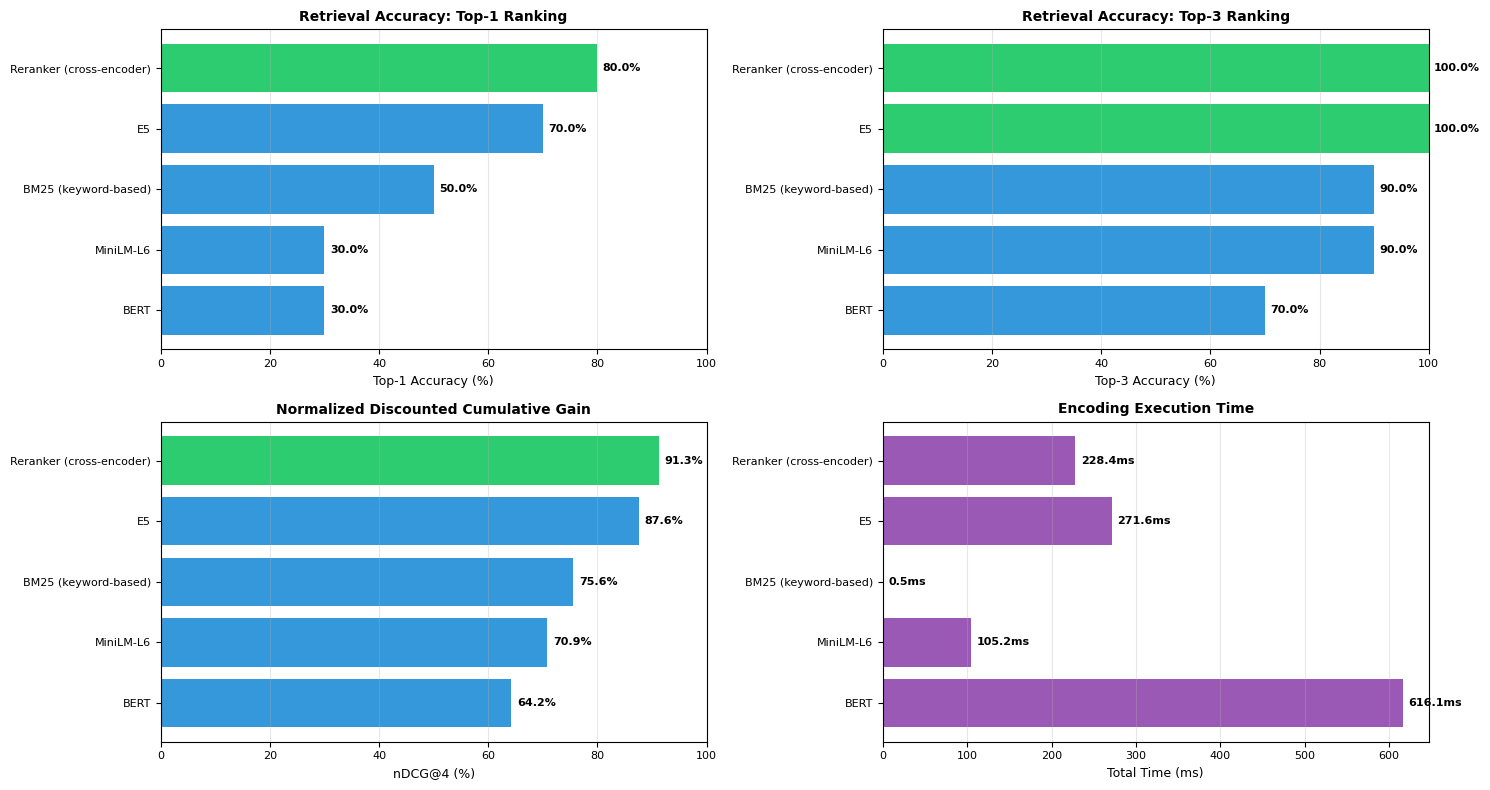

In [14]:

def visualize_metrics(results, encoding_times):
    """Create performance comparison bar charts with metrics and timing."""
    # Sort models by top1_accuracy
    model_names = [name for name, _ in sorted(results.items(), key=lambda x: x[1]['top1_accuracy'])]
    
    def draw_bar_chart(results, model_names, metric_name, title_top, title_bottom, ax):
        scores = [results[name][metric_name]*100 for name in model_names]
        max_score = max(scores)
        colors = ['#2ecc71' if score >= max_score else '#3498db' for score in scores]
        bars = ax.barh(model_names, scores, color=colors)
        ax.set_xlabel(title_top, fontsize=9)
        ax.set_title(title_bottom, fontsize=10, fontweight='bold')
        ax.set_xlim(0, 100)
        ax.grid(axis='x', alpha=0.3)
        ax.tick_params(labelsize=8)
        for i, (bar, score) in enumerate(zip(bars, scores)):
            ax.text(score + 1, i, f'{score:.1f}%', va='center', fontsize=8, fontweight='bold')
    
    fig, axes = plt.subplots(2, 2, figsize=(15, 8))
    draw_bar_chart(results, model_names, 'top1_accuracy', 'Top-1 Accuracy (%)', 'Retrieval Accuracy: Top-1 Ranking', axes[0, 0])
    draw_bar_chart(results, model_names, 'top3_accuracy', 'Top-3 Accuracy (%)', 'Retrieval Accuracy: Top-3 Ranking', axes[0, 1])
    draw_bar_chart(results, model_names, 'ndcg', 'nDCG@4 (%)', 'Normalized Discounted Cumulative Gain', axes[1, 0])
    
    # Add timing comparison
    ax_time = axes[1, 1]
    total_times = [encoding_times.get(name, 0) for name in model_names]
    total_times_ms = [t * 1000 for t in total_times]  # Convert to milliseconds
    bars = ax_time.barh(model_names, total_times_ms, color='#9b59b6')
    ax_time.set_xlabel('Total Time (ms)', fontsize=9)
    ax_time.set_title('Encoding Execution Time', fontsize=10, fontweight='bold')
    ax_time.grid(axis='x', alpha=0.3)
    ax_time.tick_params(labelsize=8)
    for i, (bar, time_ms) in enumerate(zip(bars, total_times_ms)):
        ax_time.text(time_ms + max(total_times_ms)*0.01, i, f'{time_ms:.1f}ms', va='center', fontsize=8, fontweight='bold')
    
    plt.tight_layout()
    plt.savefig('retrieval_performance_comparison.png', dpi=150, bbox_inches='tight')
    print("✓ Saved: retrieval_performance_comparison.png")
    plt.show()

visualize_metrics(metrics_results, model_manager.encoding_times)

#### Calculate and visualize similarity matrix for a selected query example

In [7]:
from ipywidgets import interact, widgets

def calculate_similarity_matrix(queries, query_data, similarities_tensor, model_names, example_q_idx=0):
    """Calculate similarity matrix for all models on an example query.
    
    Args:
        similarities_tensor: Pre-computed similarities tensor (num_queries, num_models, 4)
        model_names: List of model names in order
    """
    def truncate_text(text, max_length):
        if len(text) <= max_length:
            return text
        return text[:max_length-3] + "..."
    
    def normalize_scores(scores):
        """Normalize scores to 0-1 range for visualization."""
        score_range = scores.max() - scores.min()
        if score_range > 1e-6:  # Only normalize if there's meaningful variance
            return (scores - scores.min()) / score_range
        else:
            # All scores are nearly identical, set to middle value
            return np.full_like(scores, 0.5)
    
    # Get similarities for this query: shape (num_models, 4)
    query_similarities = similarities_tensor[example_q_idx]
    
    # Normalize BM25 and reranker scores (first and last models)
    # Embedding models (middle ones) are already normalized by cosine similarity
    similarity_matrix = query_similarities.copy()
    similarity_matrix[0] = normalize_scores(query_similarities[0])  # BM25
    similarity_matrix[-1] = normalize_scores(query_similarities[-1])  # Reranker
    
    # Get passage texts
    passage_texts = [
        query_data[example_q_idx]['relevant'],
        query_data[example_q_idx]['distractors'][0],
        query_data[example_q_idx]['distractors'][1],
        query_data[example_q_idx]['distractors'][2]
    ]
    
    # Create labels with passage content (truncate if too long)
    passage_labels = []
    for i, passage in enumerate(passage_texts):
        label = truncate_text(passage, 50)
        passage_labels.append(label)
        if i == 0:
            passage_labels[i] = "✓ " + passage_labels[i]  # Mark relevant passage
    
    # Get query text for title
    query_text = queries[example_q_idx]
    
    return similarity_matrix, model_names, passage_labels, query_text

def draw_heatmap(ax, similarity_matrix, model_labels, passage_labels, query_text, query_idx, num_queries):
    """Shared function to draw the heatmap (avoids code duplication)"""
    # Clear previous plot
    ax.clear()
    
    # Create heatmap
    im = ax.imshow(similarity_matrix, cmap='RdYlGn', aspect='auto', vmin=0, vmax=1)
    
    # Set ticks and labels
    ax.set_xticks(range(len(passage_labels)))
    ax.set_xticklabels(passage_labels, fontsize=8, rotation=15, ha='right')
    ax.set_yticks(range(len(model_labels)))
    ax.set_yticklabels([m.replace(' (', '\n(').replace(': ', ':\n') for m in model_labels], fontsize=9)
    
    # Add text annotations with similarity scores
    for i in range(len(model_labels)):
        max_j = np.argmax(similarity_matrix[i, :])
        
        for j in range(len(passage_labels)):
            sim_score = similarity_matrix[i, j]
            text_color = 'white' if sim_score < 0.35 else 'black'
            
            if j == max_j:
                rect = Rectangle((j - 0.45, i - 0.45), 0.9, 0.9, linewidth=1, edgecolor='blue', facecolor='none')
                ax.add_patch(rect)
            
            ax.text(j, i, f'{sim_score:.3f}',
                   ha="center", va="center", color=text_color,
                   fontweight='bold', fontsize=10)
    
    # Update title
    ax.set_title(f"Similarity Scores - Query {query_idx + 1}/{num_queries}: '{query_text}'",
                 fontsize=14, fontweight='bold', pad=15)
    ax.set_ylabel('Model', fontsize=12, fontweight='bold')
    ax.set_xlabel('Passage Content', fontsize=12, fontweight='bold')
    
    return im

# Show similarity heatmap

@interact(query_idx=widgets.Dropdown(
    options=[(f"Q{i+1}: {q[:50]}...", i) for i, q in enumerate(queries)],
    value=0,
    description='Query:'
))
def show_similarity_heatmap(query_idx):
    fig, ax = plt.subplots(figsize=(14, 7))
    similarity_matrix, model_labels, passage_labels, query_text = calculate_similarity_matrix(
        queries, query_data, similarities_tensor, all_model_names, example_q_idx=query_idx
    )
    im = draw_heatmap(ax, similarity_matrix, model_labels, passage_labels, query_text, query_idx, len(queries))
    plt.colorbar(im, ax=ax, label='Cosine Similarity')
    plt.tight_layout()
    plt.show()

interactive(children=(Dropdown(description='Query:', options=(('Q1: Explain Python list comprehensions...', 0)…

#### Visualize the rank of the relevant passage per model for each query

✓ Saved: ranking_comparison_all_queries.png


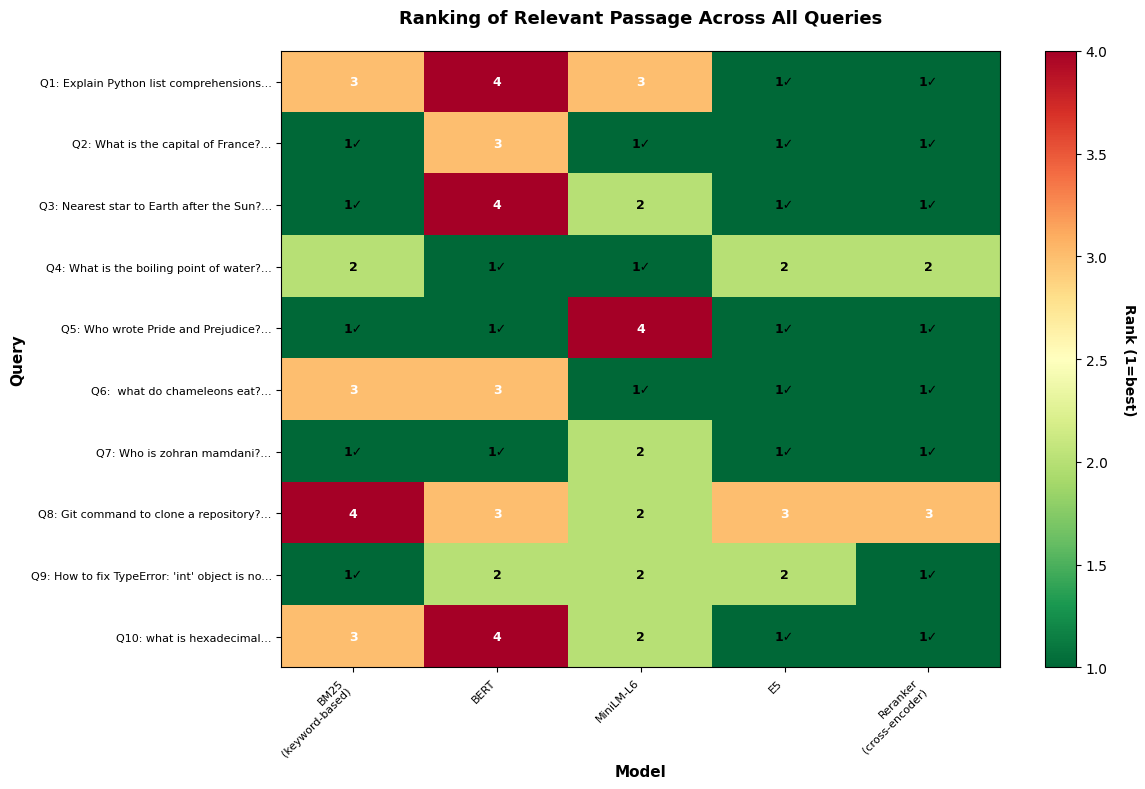

In [8]:
def calculate_rank_matrix(similarities_tensor):
    """Calculate rank matrix for all models across all queries.
    
    Args:
        similarities_tensor: Pre-computed similarities tensor (num_queries, num_models, 4)
    """
    num_queries, num_models, _ = similarities_tensor.shape
    rank_matrix = np.zeros((num_queries, num_models), dtype=int)
    
    # Calculate rank for each query and model
    for q_idx in range(num_queries):
        for m_idx in range(num_models):
            similarities = similarities_tensor[q_idx, m_idx, :]
            ranked_indices = np.argsort(similarities)[::-1]
            relevant_rank = np.where(ranked_indices == 0)[0][0] + 1
            rank_matrix[q_idx, m_idx] = relevant_rank
    
    return rank_matrix

def visualize_ranking(rank_matrix, all_model_names, queries):
    """Visualize ranking comparison heatmap."""
    fig, ax = plt.subplots(figsize=(12, 8))
    
    im = ax.imshow(rank_matrix, cmap='RdYlGn_r', aspect='auto', vmin=1, vmax=4)
    
    # Set ticks and labels
    ax.set_xticks(range(len(all_model_names)))
    ax.set_xticklabels([m.replace(' (', '\n(').replace(': ', ':\n') for m in all_model_names], 
                       fontsize=8, rotation=45, ha='right')
    ax.set_yticks(range(len(queries)))
    ax.set_yticklabels([f"Q{i+1}: {q[:40]}..." for i, q in enumerate(queries)], fontsize=8)
    
    # Add text annotations
    for i in range(len(queries)):
        for j in range(len(all_model_names)):
            rank = int(rank_matrix[i, j])
            # Black text on green/yellow (ranks 1-2), white text on red (ranks 3-4)
            color = 'black' if rank <= 2 else 'white'
            marker = '✓' if rank == 1 else ''
            ax.text(j, i, f'{rank}{marker}',
                    ha="center", va="center", color=color, fontweight='bold', fontsize=9)
    
    ax.set_title('Ranking of Relevant Passage Across All Queries', 
                 fontsize=13, fontweight='bold', pad=20)
    ax.set_ylabel('Query', fontsize=11, fontweight='bold')
    ax.set_xlabel('Model', fontsize=11, fontweight='bold')
    
    # Add colorbar
    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label('Rank (1=best)', rotation=270, labelpad=20, fontweight='bold')
    
    plt.tight_layout()
    plt.savefig('ranking_comparison_all_queries.png', dpi=150, bbox_inches='tight')
    print("✓ Saved: ranking_comparison_all_queries.png")
    plt.show()

rank_matrix = calculate_rank_matrix(similarities_tensor)
visualize_ranking(rank_matrix, all_model_names, queries)